# Notebook to simply investigate data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Für hübschere Plots, globale plot einstellungen (optional)
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams["image.cmap"] = "viridis"

rng = np.random.default_rng(0)

# Noise-Korrelation bei uniformem vs. CRT-Sampling

In diesem Notebook vergleichen wir, wie sich weißes Rauschen im k-Raum nach der Rekonstruktion im Bildraum verhält:

uniformes (kartesisches) Sampling + FFT

nicht-kartesisches CRT (concentric rings) + Density Compensation + adjoint DFT

Ziel: zeigen, dass CRT starke räumliche Rauschkorrelation erzeugt und damit z.B. Noise2Self-Annahmen verletzt.

In [2]:
# Bildgröße
N_img = 10      # N x N Bild
N_pix = N_img * N_img

# Monte Carlo-Samples für die Rauschstatistik
n_mc = 100000      # ggf. hochsetzen, dann dauert es länger

def compute_covariance(samples):
    """
    samples: Array mit Shape (n_mc, N_pix) komplex
    -> Kovarianzmatrix (N_pix, N_pix)
    """
    mean = samples.mean(axis=0, keepdims=True)
    centered = samples - mean
    Cov = (centered.conj().T @ centered) / (samples.shape[0] - 1) # Covarianzmatrix berechnen
    return Cov

def corr_map_from_cov(Cov, ref_idx):
    """
    Erzeuge Korrelationskarte zu einem Referenzpixel.
    Cov: (N_pix, N_pix)
    ref_idx: int, Index des Referenzpixels
    """
    var = Cov.diagonal().real
    ref_var = var[ref_idx]
    corr = Cov[ref_idx] / np.sqrt(ref_var * var)
    return corr.reshape(N_img, N_img)

3. Uniformes Sampling – Noise → Bild

Markdown-Zelle:

Uniformes (kartesisches) Sampling

Referenzfall:

Weißes Rauschen im kartesischen k-Raum (FFT-Gitter).

Rekonstruktion mit unitärer IFFT (norm="ortho").

Erwartung: Rauschen im Bildraum ist (annähernd) weiß und unkorreliert.

In [3]:
def simulate_uniform_noise_images(n_mc, N_img, rng):
    """
    Simuliere n_mc Bilder aus weißem Rauschen im kartesischen k-Raum.
    Rückgabe: samples mit Shape (n_mc, N_pix)
    """
    N_pix = N_img * N_img
    samples = np.empty((n_mc, N_pix), dtype=np.complex128)

    for i in range(n_mc):
        # komplexes Weißrauschen im k-Raum: i.i.d. ~ CN(0,1)
        noise_real = rng.standard_normal((N_img, N_img))
        noise_imag = rng.standard_normal((N_img, N_img))
        k_noise = (noise_real + 1j * noise_imag) / np.sqrt(2.0)

        # unitäre inverse FFT -> Bildraum
        img = np.fft.ifft2(k_noise, norm="ortho")
        samples[i] = img.ravel() # wird in der iten  zeile der montecarlo matrix gespeichert

    return samples

uniform_samples = simulate_uniform_noise_images(n_mc, N_img, rng)
uniform_samples.shape


(100000, 100)

4. Uniform: Kovarianz & Korrelation

Markdown-Zelle:

Kovarianz & Korrelation (uniform)

Wir berechnen die Kovarianzmatrix im Bildraum und visualisieren

die Varianzkarte

die Korrelationskarte zu einem Referenzpixel (Zentrum).

In [4]:
# Kovarianzmatrix für uniformes Sampling
Cov_uniform = compute_covariance(uniform_samples)
var_uniform = Cov_uniform.diagonal().real.reshape(N_img, N_img)

print("Uniform: Varianz min/max:", var_uniform.min(), var_uniform.max())

# Referenzpixel: Zentrum
cx = N_img // 2
cy = N_img // 2
ref_idx = cy * N_img + cx

corr_uniform = corr_map_from_cov(Cov_uniform, ref_idx)

# mittlere |Korrelation| außerhalb der Diagonale
corr_flat = corr_uniform.ravel()
mean_abs_corr_uniform = np.mean(np.abs(corr_flat[np.arange(N_pix) != ref_idx]))
print("Uniform: mittlere |Korrelation| außerhalb Diagonale:", mean_abs_corr_uniform)


Uniform: Varianz min/max: 0.9918936791111829 1.0059222340435194
Uniform: mittlere |Korrelation| außerhalb Diagonale: 0.0026733355131975645


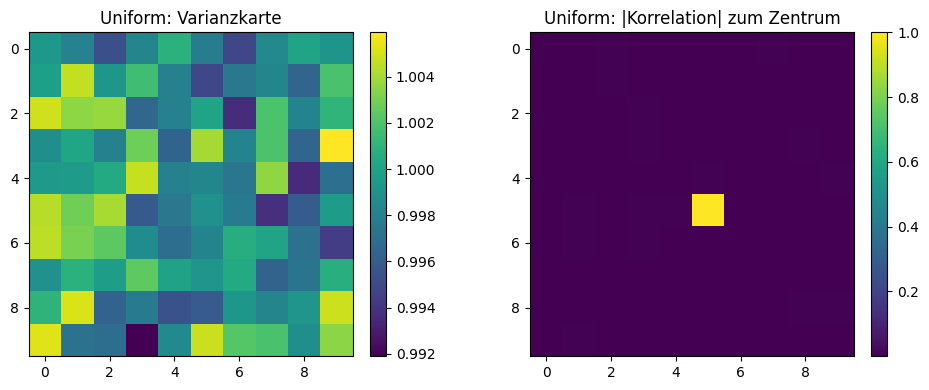

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
im0 = ax.imshow(var_uniform)
ax.set_title("Uniform: Varianzkarte")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(np.abs(corr_uniform))
ax.set_title("Uniform: |Korrelation| zum Zentrum")
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


5. CRT-Trajektorie definieren

Markdown-Zelle:

CRT-Trajektorie (2D, konzentrische Ringe)

Jetzt bauen wir eine 2D-CRT-Trajektorie:

konzentrische Ringe im Bereich 
∣k∣≤0.5
∣k∣≤0.5

auf jedem Ring 
Nθ
N
θ
	​

 Winkelpunkte

Density-Compensation 
wj=2πrj drNθ
w
j
	​

=
N
θ
	​

2πr
j
	​

dr
	​


In [ ]:
# Oversamplingfaktor im k-Raum relativ zur Pixelanzahl
oversamp_factor = 10
M_target = oversamp_factor * N_pix   # Zielanzahl k-Samples

N_rings = N_img
N_theta = int(np.ceil(M_target / N_rings))

kmax = 0.5
dr = kmax / N_rings
dtheta = 2 * np.pi / N_theta

kxs = []
kys = []
weights = []

for j in range(N_rings):
    r = (j + 0.5) * dr  # Ring-Mittelradius, ringe haben radius 1*dr 2*dr, 3*dr. Intervall ist jeweils [j*dr,(j+1)*dr], davon nimmt man mittelpunkt
    # das ist die riemannsumme mit midpoint-rule ausgewertet
    thetas = np.arange(N_theta) * dtheta

    kx = r * np.cos(thetas)
    ky = r * np.sin(thetas)

    # DC: Fläche eines Rings / Anzahl Winkelpunkte
    w = (2 * np.pi * r * dr) / N_theta

    kxs.append(kx)
    kys.append(ky)
    weights.append(np.full_like(kx, w, dtype=float))

kxs = np.concatenate(kxs)
kys = np.concatenate(kys)
weights = np.concatenate(weights)

M = kxs.size

print("CRT: total k-space points:", M)
print("kxs shape:", kxs.shape, "| weights shape:", weights.shape)


CRT: total k-space points: 100
kxs shape: (100,) | weights shape: (100,)


6. CRT-Rekonstruktion (Adjoint DFT mit DC)

Markdown-Zelle:

CRT-Rekonstruktion

Wir definieren:

Bildkoordinaten 
(x,y)
(x,y) in 
[−0.5,0.5)
[−0.5,0.5)

Fourier-Matrix 
Φm,n=exp⁡(−i2πkm⋅xn)
Φ
m,n
	​

=exp(−i2πk
m
	​

⋅x
n
	​

)

Rekonstruktion (Adjoint mit DC):

xn=∑mwm ym e+i2πkm⋅xn=(ΦH(Wy))n
x
n
	​

=
m
∑
	​

w
m
	​

y
m
	​

e
+i2πk
m
	​

⋅x
n
	​

=(Φ
H
(Wy))
n
	​

In [7]:
# Bildkoordinaten (x,y) in [-0.5, 0.5)
coords_1d = (np.arange(N_img) - N_img / 2) / N_img
X, Y = np.meshgrid(coords_1d, coords_1d, indexing="xy")
positions = np.stack([X.ravel(), Y.ravel()], axis=1)  # (N_pix, 2)

# k-Vektoren
k = np.stack([kxs, kys], axis=1)  # (M, 2)

# Skalarprodukt k·x für alle m,n, wichtig für phase
k_dot_x = k @ positions.T  # (M, N_pix)

# Fourier-Matrix
Phi = np.exp(-2j * np.pi * k_dot_x)  # (M, N_pix)

weights_complex = weights.astype(np.complex128)

def reconstruct_crt_noise(y):
    """
    y: (M,) komplexes k-Raum-Rauschen
    -> (N_pix,) komplexes Bild im Bildraum
    """
    y_dc = weights_complex * y
    x = Phi.conj().T @ y_dc #Forward operator entspricht inverser Fourier Trafo
    return x


7. CRT: Noise → Bild (Monte Carlo)

Markdown-Zelle:

CRT: Rauschen im k-Raum → Bild

Wir simulieren wieder weißes Rauschen im k-Raum, rekonstruieren per CRT-Adjoint und speichern alle Realisierungen.

In [8]:
def simulate_crt_noise_images(n_mc, rng):
    samples = np.empty((n_mc, N_pix), dtype=np.complex128)

    for i in range(n_mc):
        # komplexes Weißrauschen im CRT-k-Raum
        noise_real = rng.standard_normal(M)
        noise_imag = rng.standard_normal(M)
        y_noise = (noise_real + 1j * noise_imag) / np.sqrt(2.0)

        img = reconstruct_crt_noise(y_noise)
        samples[i] = img

    return samples

crt_samples = simulate_crt_noise_images(n_mc, rng)
crt_samples.shape


(100000, 100)

8. CRT: Kovarianz & Korrelation

Markdown-Zelle:

Kovarianz & Korrelation (CRT)

Jetzt berechnen wir wieder Varianz- und Korrelationskarten im Bildraum – diesmal für CRT.

In [9]:
Cov_crt = compute_covariance(crt_samples)
var_crt = Cov_crt.diagonal().real.reshape(N_img, N_img)

print("CRT: Varianz min/max:", var_crt.min(), var_crt.max())

corr_crt = corr_map_from_cov(Cov_crt, ref_idx)
corr_flat_crt = corr_crt.ravel()
mean_abs_corr_crt = np.mean(np.abs(corr_flat_crt[np.arange(N_pix) != ref_idx]))
print("CRT: mittlere |Korrelation| außerhalb Diagonale:", mean_abs_corr_crt)


CRT: Varianz min/max: 0.008164940245630853 0.008250266661994025
CRT: mittlere |Korrelation| außerhalb Diagonale: 0.772518940610648


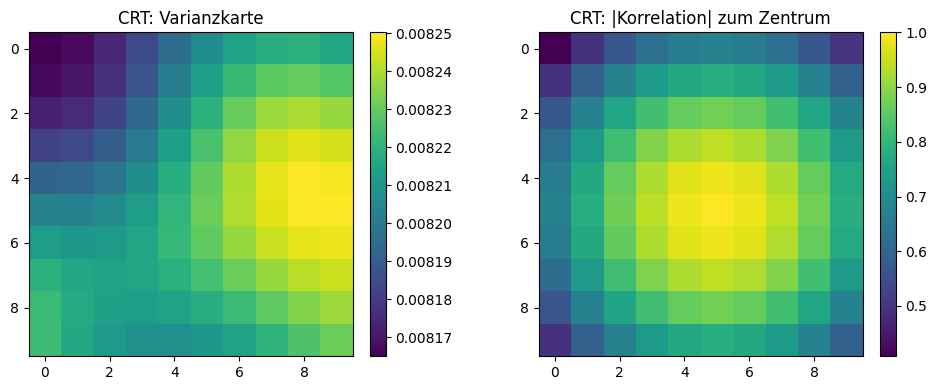

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
im0 = ax.imshow(var_crt)
ax.set_title("CRT: Varianzkarte")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(np.abs(corr_crt))
ax.set_title("CRT: |Korrelation| zum Zentrum")
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Rekonstruktionsmatrix L explizit aufbauen (nur zum Check, ist groß aber für 32x32 ok)
# Phi.shape = (M, N_pix), weights_complex.shape = (M,)
L = Phi.conj().T * weights_complex[np.newaxis, :]  # Shape: (N_pix, M)




In [11]:
# 1) Varianz direkt aus den Samples
var_mc = np.var(crt_samples, axis=0, ddof=1)          # (N_pix,)
var_mc_img = var_mc.reshape(N_img, N_img)

print("MC-Varianz min/max:", var_mc.min(), var_mc.max())

# 2) Varianz aus Kovarianz-Diagonale
Cov_crt = compute_covariance(crt_samples)
var_cov = Cov_crt.diagonal().real
var_cov_img = var_cov.reshape(N_img, N_img)

print("Cov-Varianz min/max:", var_cov.min(), var_cov.max())

# 3) Differenz
print("max |var_mc - var_cov|:", np.max(np.abs(var_mc - var_cov)))


MC-Varianz min/max: 0.008164940245630893 0.008250266661994141
Cov-Varianz min/max: 0.008164940245630853 0.008250266661994025
max |var_mc - var_cov|: 2.2898349882893854e-16


9. Vergleich & Beispielbilder

Markdown-Zelle:

Vergleich: Uniform vs. CRT

Zum Abschluss vergleichen wir:

ein Beispiel-Rauschbild (Realteil) für beide Methoden

Varianz- und Korrelationskarten nebeneinander.

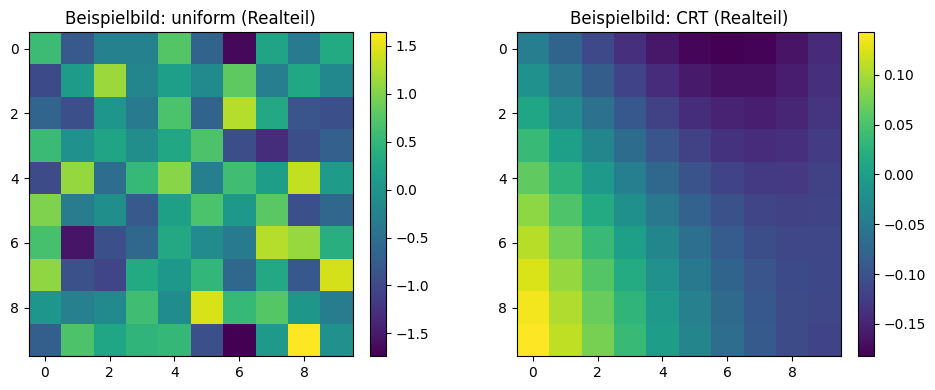

In [12]:
# Beispiel-Realisationen (Realteil) für beide Fälle
img_uniform_example = uniform_samples[0].reshape(N_img, N_img)
img_crt_example = crt_samples[0].reshape(N_img, N_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
im0 = ax.imshow(img_uniform_example.real)
ax.set_title("Beispielbild: uniform (Realteil)")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(img_crt_example.real)
ax.set_title("Beispielbild: CRT (Realteil)")
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


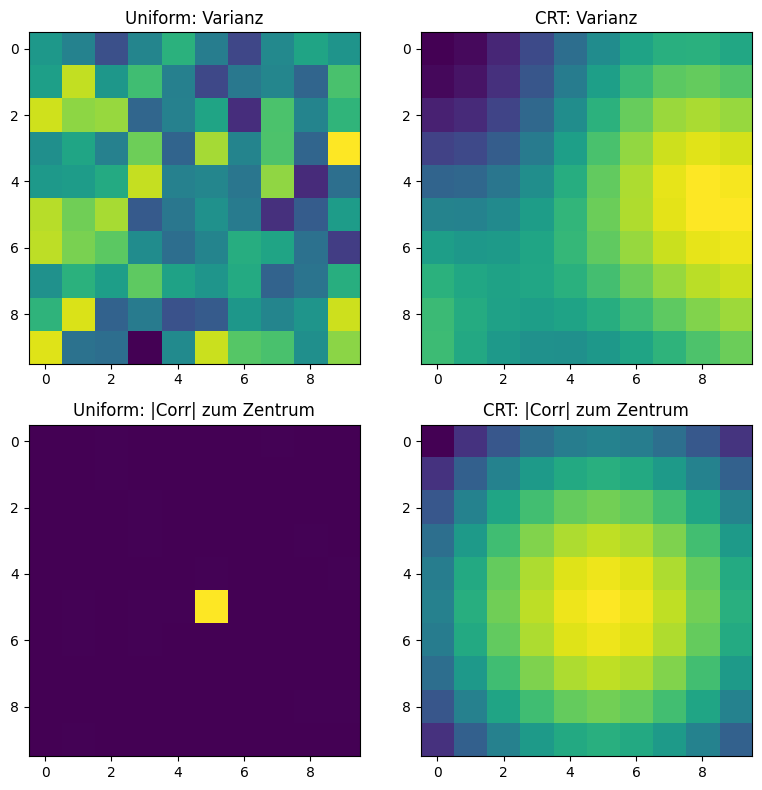

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(var_uniform)
axes[0, 0].set_title("Uniform: Varianz")

axes[0, 1].imshow(var_crt)
axes[0, 1].set_title("CRT: Varianz")

axes[1, 0].imshow(np.abs(corr_uniform))
axes[1, 0].set_title("Uniform: |Corr| zum Zentrum")

axes[1, 1].imshow(np.abs(corr_crt))
axes[1, 1].set_title("CRT: |Corr| zum Zentrum")

plt.tight_layout()
plt.show()


In [14]:
# Rekonstruktionsmatrix L explizit aufbauen (nur zum Check, ist groß aber für 32x32 ok)
# Phi.shape = (M, N_pix), weights_complex.shape = (M,)
L = Phi.conj().T * weights_complex[np.newaxis, :]  # Shape: (N_pix, M)

row_norms = np.sum(np.abs(L)**2, axis=1)  # Norm^2 jeder Zeile
print("min row_norm^2:", row_norms.min())
print("max row_norm^2:", row_norms.max())


min row_norm^2: 0.008204108658405528
max row_norm^2: 0.008204108658405533
